In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import trange,tqdm
import pickle
import matplotlib.pyplot as plt
from math import ceil
import scipy
import scipy.signal
import itertools
import sys, os
import scipy.stats as sts
from scipy.stats import sem
from scipy.stats import pearsonr, sem
import numpy.random as npr
import pandas as pd
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler
import ast
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score

In [2]:
# Now try reading it
with open('C:/Users/shahe/PycharmProjects/distributed_SD/Data/filtered_mocol_categorization_bin_0.05.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        def clean(val):
            if isinstance(val, np.ndarray):
                return str(val[0]) if len(val) > 0 else None
            return str(val) if val is not None else None

        df['chosenResponse'] = df['chosenResponse'].apply(clean)
        df['expectedResponse'] = df['expectedResponse'].apply(clean)
        df['color'] = df['color']/90
        df['direction'] = df['direction']/90
        data['trial'][i] = df  # Save cleaned DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")


for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        # Map values
        df['chosenResponse'] = df['chosenResponse'].map({'L': 1, 'R': 0})
        df['expectedResponse'] = df['expectedResponse'].map({'L': 1, 'R': 0})
        data['trial'][i] = df  # Save updated DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")

for i, df in enumerate(data['trial']):
    if 'rule' in df.columns:
        # Extract the string from the array and map it to numeric
        df['rule'] = df['rule'].apply(
            lambda x: 1 if isinstance(x, (list, np.ndarray)) and 'color' in x else
                      -1 if isinstance(x, (list, np.ndarray)) and 'motion' in x else
                      np.nan  # fallback for unexpected format
        )
        data['trial'][i] = df  # Update cleaned DataFrame

In [4]:
data = data['trial']

In [5]:
def process_session_data(df):
    """
    Process a single session DataFrame.
    Cleans and adds derived variables for analysis, including cue encoding.
    """
    df = df.copy()
    scaler = StandardScaler()

    # Basic columns
    df['intercept'] = 1

    # Raw stimulus variables
    df['color_z'] = df['color']
    df['direction_z'] = df['direction']

    # Previous trial variables
    df['p_color_z'] = df['color_z'].shift(1)
    df['p_direction_z'] = df['direction_z'].shift(1)

    # relevant stimulus when rule is 1 --> color and when rule is -1 --> motion
    df['relevant_stim'] = df.apply(
        lambda row: row['color_z'] if row['rule'] == 1 else row['direction_z'], axis=1
    )
    df['irrelevant_stim'] = df.apply(
        lambda row: row['direction_z'] if row['rule'] == 1 else row['color_z'], axis=1
    )

    df['prev_relevant_stim'] = df['relevant_stim'].shift(1)
    df['prev_irrelevant_stim'] = df['irrelevant_stim'].shift(1)


    # ---------------- Add is_correct ----------------
    # 1 if chosenResponse == expectedResponse
    # 0 if not equal
    # 2 if expectedResponse is NaN
    is_nan_exp = df['expectedResponse'].isna()
    matches = df['chosenResponse'] == df['expectedResponse']
    df['is_correct'] = np.select([is_nan_exp, matches], [2, 1], default=0).astype(int)

    # probability correct and incorect
    df['prob_correct'] = np.where(df['is_correct'] == 1, 1, 0)
    df['prob_incorrect'] = np.where(df['is_correct'] == 0, 1, 0)
    df['prob_neurtral'] = np.where(df['is_correct'] == 2, 1, 0)




    
    df['prev_response'] = df['chosenResponse'].shift(1)

    # Rule/context
    df['context'] = df['rule']
    df['prev_context'] = df['context'].shift(1)

    df['color_ctx'] = df['color_z']*df['context']
    df['direction_ctx'] = df['direction_z']*df['context']

    df['prev_res_ctx'] = df['prev_response']*df['context']

    # Filter trials: good timing only
    good_mask = df['badTimingTrials'] == 0
    df_filtered = df[good_mask].reset_index(drop=True)

    # Normalize reaction time
    df_filtered['reactionTime_z'] = scaler.fit_transform(df_filtered[['reactionTime']])
    

    # One-hot encode cue (4 categories)
    cue_dummies = pd.get_dummies(df_filtered['cue'], prefix='cue', drop_first=False)
    df_filtered = pd.concat([df_filtered, cue_dummies], axis=1)

    # let's filter only the correct trials
    #df_filtered = df_filtered[df_filtered['is_correct'] == 1].reset_index(drop=True)

    # let's filter only incorrect trials
    #df_filtered = df_filtered[df_filtered['is_correct'] == 0].reset_index(drop=True)


    return df_filtered

def prepare_data_for_glmhmm_sessionwise(data):
    """
    Prepares input features and responses for HMM-GLM model fitting.
    Returns separate input arrays per session (no concatenation).
    """
    inpts = []
    true_choices = []
    session_lengths = []

    for df in data:
        # Extract features (negated for consistency with logistic loss convention)
        color         = df[['color_z']].fillna(0).to_numpy()
        motion        = df[['direction_z']].fillna(0).to_numpy()
        p_color       = df[['p_color_z']].fillna(0).to_numpy()
        p_motion      = df[['p_direction_z']].fillna(0).to_numpy()
        prev_response = df[['prev_response']].fillna(0).to_numpy()
        color_ctx    = df[['color_ctx']].fillna(0).to_numpy()
        direction_ctx = df[['direction_ctx']].fillna(0).to_numpy()
        prev_res_ctx = df[['prev_res_ctx']].fillna(0).to_numpy()
        context       = df[['context']].fillna(0).to_numpy()
        relevant_stim = df[['relevant_stim']].fillna(0).to_numpy()
        irrelevant_stim = df[['irrelevant_stim']].fillna(0).to_numpy()
        prev_relevant_stim = df[['prev_relevant_stim']].fillna(0).to_numpy()
        prev_irrelevant_stim = df[['prev_irrelevant_stim']].fillna(0).to_numpy()



        bias          = df[['intercept']].fillna(0).to_numpy()

        # Cue dummies (cue_0, cue_1, cue_2, cue_3)
        cue_cols = [col for col in df.columns if col.startswith('cue_')]
        cue_dummies = df[cue_cols].fillna(0).astype(int).to_numpy()


        # Combine all into feature matrix
        X = np.hstack([
            #color,
            #motion,
            #p_color,
            #dist_prev_c,
            #p_motion,
            #dist_prev_m,
            relevant_stim,
            irrelevant_stim,
            prev_relevant_stim,
            prev_irrelevant_stim,
            prev_response,
            #color_ctx,
            #direction_ctx,
            #context,
            #ue_dummies,
            bias
        ])

        # Response variable
        y = df['chosenResponse'].fillna(0).astype(int).to_numpy().reshape(-1, 1)

        # Save session data
        inpts.append(X)
        true_choices.append(y)
        session_lengths.append(len(df))

    return inpts, true_choices, session_lengths


# Assuming `data` is a list of session DataFrames:
processed_data = [process_session_data(df) for df in data]
inpts, true_choices, session_lengths = prepare_data_for_glmhmm_sessionwise(processed_data)

# Determine input dimensionality
input_dim = inpts[0].shape[1]

In [6]:
# --- Make sure FEATURE_NAMES matches your X stacking order in prepare_data_for_glmhmm_sessionwise ---
FEATURE_NAMES = [
    "relevant_stim",
    "irrelevant_stim",
    "prev_relevant_stim",
    "prev_irrelevant_stim",
    "prev_response",
    "intercept",
]

def _prepare_xy(X_list, y_list):
    X = np.asarray(X_list)
    y = np.asarray(y_list)
    if y.ndim == 2 and y.shape[1] == 1:
        y = y.ravel()
    return X, y

def fit_logreg(X, y, C=1.0, class_weight=None, max_iter=2000, random_state=0):
    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=random_state,
    )
    model.fit(X, y)
    return model

def summarize_model(model, X, y, feature_names=FEATURE_NAMES, name="model"):
    proba = model.predict_proba(X)[:, 1]
    yhat  = (proba >= 0.5).astype(int)

    acc = accuracy_score(y, yhat)
    try:
        auc = roc_auc_score(y, proba)
    except ValueError:
        auc = np.nan
    cm = confusion_matrix(y, yhat, labels=[0,1])

    coef = model.coef_.ravel()
    intercept = float(model.intercept_.item()) if model.intercept_.size == 1 else model.intercept_
    coef_table = [
        {"feature": nm, "beta": float(b), "odds_ratio": float(np.exp(b))}
        for nm, b in zip(feature_names, coef)
    ]
    coef_table.append({"feature": "intercept_(model_intercept_)", "beta": intercept, "odds_ratio": float(np.exp(intercept))})
    print(f"\n=== {name} ===")
    print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
    print(f"Accuracy: {acc:.3f} | ROC-AUC: {auc if auc==auc else float('nan'):.3f}")
    print("Confusion matrix [rows=true 0/1, cols=pred 0/1]:")
    print(cm)
    print("Top coefficients (by |beta|):")
    top = sorted(coef_table[:-1], key=lambda d: abs(d["beta"]), reverse=True)
    for row in top:
        print(f"  {row['feature']:>20s}  beta={row['beta']: .4f}  OR={row['odds_ratio']: .4f}")
    print("\nClassification report:")
    print(classification_report(y, yhat, digits=3, zero_division=0))
    return {"accuracy": acc, "roc_auc": auc, "confusion_matrix": cm, "coef_table": coef_table}

# ---------- Build pooled arrays + masks aligned across sessions ----------
X_blocks, y_blocks, mask_corr_neu_blocks, mask_inc_blocks = [], [], [], []
for df_session, X_session, y_session in zip(processed_data, inpts, true_choices):
    # masks based on processed_data's is_correct
    is_corr_neu = df_session['is_correct'].isin([1,2]).to_numpy()
    is_incorrect = df_session['is_correct'].eq(0).to_numpy()

    # keep alignment (prepare_data_for_glmhmm_sessionwise returns in same row order)
    X_blocks.append(X_session)
    y_blocks.append(y_session.reshape(-1, 1))
    mask_corr_neu_blocks.append(is_corr_neu.reshape(-1, 1))
    mask_inc_blocks.append(is_incorrect.reshape(-1, 1))

X_all = np.vstack(X_blocks)
y_all = np.vstack(y_blocks)
mask_corr_neu = np.vstack(mask_corr_neu_blocks).ravel().astype(bool)
mask_incorrect = np.vstack(mask_inc_blocks).ravel().astype(bool)

X_all, y_all = _prepare_xy(X_all, y_all)

# ---------- Split by correctness for training ----------
X_corr_neu = X_all[mask_corr_neu]
y_corr_neu = y_all[mask_corr_neu]

X_incorrect = X_all[mask_incorrect]
y_incorrect = y_all[mask_incorrect]

# Fit two GLMs
glm_corr_neu = fit_logreg(X_corr_neu, y_corr_neu, C=1.0, class_weight=None, max_iter=2000, random_state=0)
glm_incorrect = fit_logreg(X_incorrect, y_incorrect, C=1.0, class_weight=None, max_iter=2000, random_state=0)

# Summaries per group (on their own training data, or swap in held-out data if you have it)
_ = summarize_model(glm_corr_neu, X_corr_neu, y_corr_neu, FEATURE_NAMES, name="GLM on correct+neutral trials")
_ = summarize_model(glm_incorrect, X_incorrect, y_incorrect, FEATURE_NAMES, name="GLM on incorrect trials")

# ---------- Overall evaluation using group-appropriate model per trial ----------
proba_mix = np.empty(y_all.shape[0], dtype=float)

# Use the group-specific model to score each subset
if mask_corr_neu.any():
    proba_mix[mask_corr_neu] = glm_corr_neu.predict_proba(X_all[mask_corr_neu])[:, 1]
if mask_incorrect.any():
    proba_mix[mask_incorrect] = glm_incorrect.predict_proba(X_all[mask_incorrect])[:, 1]

yhat_mix = (proba_mix >= 0.5).astype(int)

overall_acc = accuracy_score(y_all, yhat_mix)
try:
    overall_auc = roc_auc_score(y_all, proba_mix)
except ValueError:
    overall_auc = np.nan
overall_cm = confusion_matrix(y_all, yhat_mix, labels=[0,1])

print("\n=== Overall evaluation (using GLM-correct+neutral for corr/neu trials and GLM-incorrect for incorrect trials) ===")
print(f"Samples: {X_all.shape[0]}")
print(f"Accuracy: {overall_acc:.3f} | ROC-AUC: {overall_auc if overall_auc==overall_auc else float('nan'):.3f}")
print("Confusion matrix [rows=true 0/1, cols=pred 0/1]:")
print(overall_cm)
print("\nClassification report:")
print(classification_report(y_all, yhat_mix, digits=3, zero_division=0))





=== GLM on correct+neutral trials ===
Samples: 51236, Features: 6
Accuracy: 0.945 | ROC-AUC: 0.991
Confusion matrix [rows=true 0/1, cols=pred 0/1]:
[[21485  2821]
 [    0 26930]]
Top coefficients (by |beta|):
         relevant_stim  beta= 30.0376  OR= 11095505032620.9395
       irrelevant_stim  beta= 1.6950  OR= 5.4466
             intercept  beta= 0.2131  OR= 1.2376
    prev_relevant_stim  beta=-0.2065  OR= 0.8134
  prev_irrelevant_stim  beta=-0.1101  OR= 0.8957
         prev_response  beta=-0.0033  OR= 0.9967

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.884     0.938     24306
           1      0.905     1.000     0.950     26930

    accuracy                          0.945     51236
   macro avg      0.953     0.942     0.944     51236
weighted avg      0.950     0.945     0.945     51236


=== GLM on incorrect trials ===
Samples: 6130, Features: 6
Accuracy: 1.000 | ROC-AUC: 1.000
Confusion matrix [rows=true 0/1, cols=

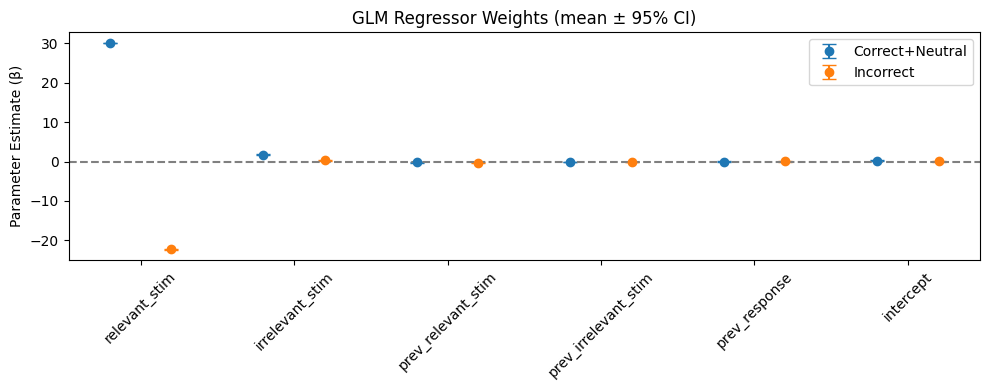

In [7]:
regressor_labels = FEATURE_NAMES

# Arrays shaped (n_regressors,), from glm_corr_neu and glm_incorrect
betas_corr_neu = glm_corr_neu.coef_.ravel()
betas_incorrect = glm_incorrect.coef_.ravel()

ci95_corr_neu = np.full_like(betas_corr_neu, 0.1)
ci95_incorrect = np.full_like(betas_incorrect, 0.1)

x = np.arange(len(regressor_labels))
width = 0.2  # horizontal offset

plt.figure(figsize=(10, 4))

# Correct+Neutral GLM weights
plt.errorbar(
    x - width, betas_corr_neu, yerr=ci95_corr_neu,
    fmt='o', capsize=5, label='Correct+Neutral', color='C0'
)

# Incorrect GLM weights
plt.errorbar(
    x + width, betas_incorrect, yerr=ci95_incorrect,
    fmt='o', capsize=5, label='Incorrect', color='C1'
)

plt.axhline(0, linestyle='--', color='gray')
plt.xticks(x, regressor_labels, rotation=45)
plt.ylabel('Parameter Estimate (β)')
plt.title('GLM Regressor Weights (mean ± 95% CI)')
plt.legend()
plt.tight_layout()
plt.show()


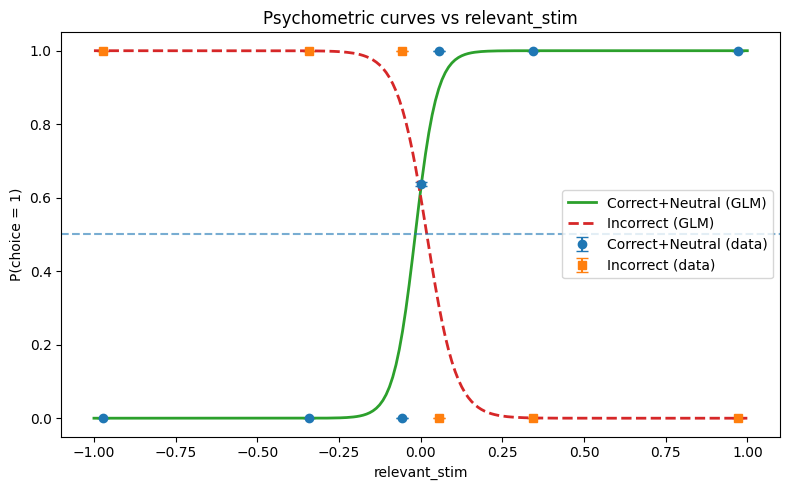

In [13]:
def plot_two_psychometric_curves(
    model_a, model_b,
    X_all, y_all,
    feature_names,
    stim_name="relevant_stim",
    mask_a=None, mask_b=None,
    label_a="Correct+Neutral",
    label_b="Incorrect",
    nbins=35,
    grid_points=200,
    hold_strategy="mean"  # "mean" or "zero"
):
    """
    Plot fitted psychometric curves (P(choice=1) vs stim) and empirical mean±SEM
    for two GLMs fitted on disjoint subsets (e.g., correct+neutral vs incorrect).

    Parameters
    ----------
    model_a, model_b : fitted sklearn LogisticRegression
        Trained with fit_intercept=False if 'intercept' is in feature_names.
    X_all : (N, D) ndarray
        Full pooled design matrix.
    y_all : (N,) ndarray
        Binary choices (0/1).
    feature_names : list[str]
        Names for columns in X_all (order must match X_all).
    stim_name : str
        Column name to sweep for the psychometric curve.
    mask_a, mask_b : (N,) boolean arrays
        Masks indicating which trials belong to each model's subset.
    label_a, label_b : str
        Labels for legend.
    """

    # --- basic checks and slicing ---
    X = np.asarray(X_all)
    y = np.asarray(y_all).ravel()
    assert stim_name in feature_names, f"{stim_name} not in feature_names."
    stim_idx = feature_names.index(stim_name)

    if mask_a is None or mask_b is None:
        raise ValueError("mask_a and mask_b must be provided (booleans of length N).")

    # masks & finite data
    finite_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    mask_a = (mask_a.astype(bool) & finite_mask)
    mask_b = (mask_b.astype(bool) & finite_mask)
    X_a, y_a = X[mask_a], y[mask_a]
    X_b, y_b = X[mask_b], y[mask_b]

    # --- ranges per subset (union for a shared x-axis) ---
    s_a = X_a[:, stim_idx]
    s_b = X_b[:, stim_idx]
    s_min = np.nanmin(np.concatenate([s_a, s_b]))
    s_max = np.nanmax(np.concatenate([s_a, s_b]))
    s_grid = np.linspace(s_min, s_max, grid_points)

    # --- base vectors for grid (hold non-stim covariates) ---
    def base_vec(Xblock):
        if hold_strategy == "mean":
            b = np.nanmean(Xblock, axis=0)
        elif hold_strategy == "zero":
            b = np.zeros(Xblock.shape[1], dtype=float)
            if "intercept" in feature_names:
                b[feature_names.index("intercept")] = 1.0
        else:
            raise ValueError("hold_strategy must be 'mean' or 'zero'")
        if "intercept" in feature_names:
            b[feature_names.index("intercept")] = 1.0
        return b

    base_a = base_vec(X_a)
    base_b = base_vec(X_b)

    # --- build grid design matrices per subset and predict ---
    Xgrid_a = np.tile(base_a, (grid_points, 1))
    Xgrid_b = np.tile(base_b, (grid_points, 1))
    Xgrid_a[:, stim_idx] = s_grid
    Xgrid_b[:, stim_idx] = s_grid

    probs_a = model_a.predict_proba(Xgrid_a)[:, 1]
    probs_b = model_b.predict_proba(Xgrid_b)[:, 1]

    # --- empirical means (bin within each subset) ---
    def binned_means(stim_vals, y_vals, nbins):
        edges = np.linspace(s_min, s_max, nbins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])
        idx = np.digitize(stim_vals, edges, right=False) - 1
        idx = np.clip(idx, 0, nbins - 1)
        mean_emp = np.full(nbins, np.nan)
        sem_emp = np.full(nbins, np.nan)
        counts = np.zeros(nbins, dtype=int)
        for b in range(nbins):
            m = (idx == b)
            if np.any(m):
                yb = y_vals[m]
                counts[b] = yb.size
                mean_emp[b] = np.mean(yb)
                sem_emp[b] = (np.std(yb, ddof=1) / np.sqrt(yb.size)) if yb.size > 1 else 0.0
        return centers, mean_emp, sem_emp, counts

    c_a, m_a, se_a, n_a = binned_means(s_a, y_a, nbins)
    c_b, m_b, se_b, n_b = binned_means(s_b, y_b, nbins)

    # --- plot ---
    plt.figure(figsize=(8, 5))

    # empirical points
    plt.errorbar(c_a, m_a, yerr=se_a, fmt='o', capsize=4, label=f'{label_a} (data)')
    plt.errorbar(c_b, m_b, yerr=se_b, fmt='s', capsize=4, label=f'{label_b} (data)')

    # fitted curves
    plt.plot(s_grid, probs_a, linewidth=2, label=f'{label_a} (GLM)')
    plt.plot(s_grid, probs_b, linewidth=2, linestyle='--', label=f'{label_b} (GLM)')

    plt.axhline(0.5, linestyle='--', alpha=0.6)
    plt.ylim(-0.05, 1.05)
    plt.xlabel(stim_name)
    plt.ylabel('P(choice = 1)')
    plt.title(f'Psychometric curves vs {stim_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "stim_grid": s_grid,
        f"probs_{label_a}": probs_a,
        f"probs_{label_b}": probs_b,
        f"bin_centers_{label_a}": c_a,
        f"mean_emp_{label_a}": m_a,
        f"sem_emp_{label_a}": se_a,
        f"counts_{label_a}": n_a,
        f"bin_centers_{label_b}": c_b,
        f"mean_emp_{label_b}": m_b,
        f"sem_emp_{label_b}": se_b,
        f"counts_{label_b}": n_b,
    }

_ = plot_two_psychometric_curves(
    model_a=glm_corr_neu,
    model_b=glm_incorrect,
    X_all=X_all,
    y_all=y_all,
    feature_names=FEATURE_NAMES,
    stim_name="relevant_stim",  # or "irrelevant_stim" depending on what you want to show
    mask_a=mask_corr_neu,
    mask_b=mask_incorrect,
    label_a="Correct+Neutral",
    label_b="Incorrect",
    nbins=35,
    grid_points=200,
    hold_strategy="mean"  # or "zero"
)


In [16]:
# --- Define logistic regression model (same as before) ---
logreg_cv = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    fit_intercept=False,   # IMPORTANT: we already have an 'intercept' column
    random_state=0
)

# --- Cross-validation setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def cv_scores(X, y, label=""):
    acc_scores = cross_val_score(logreg_cv, X, y, cv=cv, scoring="accuracy")
    roc_scores = cross_val_score(logreg_cv, X, y, cv=cv, scoring="roc_auc")
    print(f"\n=== {label} ===")
    print(f"Samples: {X.shape[0]}")
    print(f"Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
    print(f"ROC-AUC : {roc_scores.mean():.3f} ± {roc_scores.std():.3f}")

# --- Evaluate separately ---
X_corr_neu, y_corr_neu = X_all[mask_corr_neu], y_all[mask_corr_neu]
X_incorrect, y_incorrect = X_all[mask_incorrect], y_all[mask_incorrect]

cv_scores(X_corr_neu, y_corr_neu, label="Correct+Neutral trials")
cv_scores(X_incorrect, y_incorrect, label="Incorrect trials")





=== Correct+Neutral trials ===
Samples: 51236
Accuracy: 0.945 ± 0.002
ROC-AUC : 0.990 ± 0.000

=== Incorrect trials ===
Samples: 6130
Accuracy: 1.000 ± 0.000
ROC-AUC : 1.000 ± 0.000


In [17]:
# --- Setup logistic regression template ---
def make_logreg():
    return LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        fit_intercept=False,   # IMPORTANT: 'intercept' already in X
        random_state=0
    )

# --- Stratified CV setup (stratify on y_all to balance choices) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

acc_scores = []
roc_scores = []

for train_idx, test_idx in cv.split(X_all, y_all):
    # Split train/test
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    mask_train_corr = mask_corr_neu[train_idx]
    mask_train_inc  = mask_incorrect[train_idx]
    mask_test_corr  = mask_corr_neu[test_idx]
    mask_test_inc   = mask_incorrect[test_idx]

    # --- Fit separate models on training subsets ---
    glm_corr = make_logreg().fit(X_train[mask_train_corr], y_train[mask_train_corr])
    glm_inc  = make_logreg().fit(X_train[mask_train_inc],  y_train[mask_train_inc])

    # --- Predict on test subsets ---
    proba_mix = np.zeros(len(test_idx))
    if mask_test_corr.any():
        proba_mix[mask_test_corr] = glm_corr.predict_proba(X_test[mask_test_corr])[:, 1]
    if mask_test_inc.any():
        proba_mix[mask_test_inc] = glm_inc.predict_proba(X_test[mask_test_inc])[:, 1]

    yhat_mix = (proba_mix >= 0.5).astype(int)

    # --- Scores ---
    acc = accuracy_score(y_test, yhat_mix)
    try:
        auc = roc_auc_score(y_test, proba_mix)
    except ValueError:
        auc = np.nan

    acc_scores.append(acc)
    roc_scores.append(auc)

# --- Final summary ---
acc_scores = np.array(acc_scores)
roc_scores = np.array(roc_scores)

print("\n=== Overall cross-validated evaluation (mixed models) ===")
print(f"Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"ROC-AUC : {roc_scores.mean():.3f} ± {roc_scores.std():.3f}")



=== Overall cross-validated evaluation (mixed models) ===
Accuracy: 0.951 ± 0.001
ROC-AUC : 0.992 ± 0.000
